# 01 - FiQA-2018: what is actually in this corpus

Before building a retriever it is worth knowing what it has to retrieve
*from*. Two questions decide design choices later in this project:

1. **How long are the documents?** Bi-encoders have a hard token limit and
   silently truncate past it. If a large share of the corpus runs past that
   limit, the encoder is not embedding the documents -- it is embedding
   their opening paragraphs.
2. **How many relevant documents does a question have?** That sets the
   ceiling on `Recall@k` and decides how many passages to feed the
   generator.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import load_split, doc_text

sns.set_theme(style="whitegrid")
corpus, queries, qrels = load_split("test")
print(f"corpus  : {len(corpus):,} documents")
print(f"queries : {len(queries):,} test questions with relevance judgments")
print(f"judged  : {sum(len(v) for v in qrels.values()):,} (question, document) pairs")

corpus  : 57,638 documents
queries : 648 test questions with relevance judgments
judged  : 1,706 (question, document) pairs


## The documents

FiQA's corpus is financial forum answers (StackExchange / Reddit personal
finance), not curated articles.

In [2]:
texts = [doc_text(d) for d in corpus.values()]
chars = np.array([len(t) for t in texts])
words = np.array([len(t.split()) for t in texts])

print(f"characters  mean={chars.mean():.0f}  median={np.median(chars):.0f}  "
      f"p90={np.percentile(chars, 90):.0f}  p99={np.percentile(chars, 99):.0f}  max={chars.max():,}")
print(f"words       mean={words.mean():.0f}  median={np.median(words):.0f}  "
      f"p90={np.percentile(words, 90):.0f}")
print(f"empty documents : {(chars == 0).sum()}")
print(f"with a title    : {sum(1 for d in corpus.values() if d['title'].strip()):,}")

characters  mean=767  median=522  p90=1551  p99=3698  max=16,990
words       mean=133  median=90  p90=270
empty documents : 38
with a title    : 0


38 documents are empty and none has a title. The empty ones are left in:
removing them would change the corpus the published BEIR numbers were
computed on, and 38 out of 57,638 cannot move a metric. It is worth knowing
they are there, not worth 'fixing'.

The length distribution is heavily right-skewed -- a median of 522
characters with a maximum near 17,000.

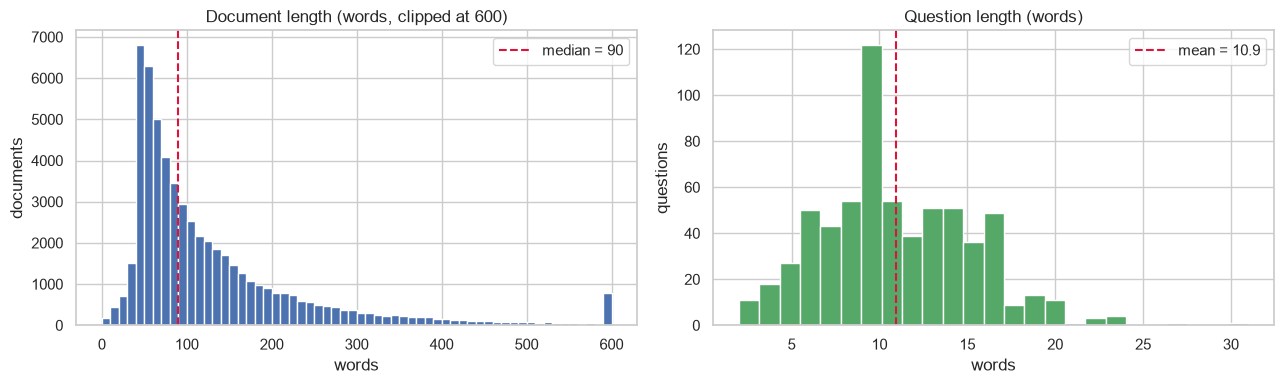

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(np.clip(words, 0, 600), bins=60, color="#4C72B0")
axes[0].set(title="Document length (words, clipped at 600)", xlabel="words", ylabel="documents")
axes[0].axvline(np.median(words), color="crimson", ls="--", label=f"median = {np.median(words):.0f}")
axes[0].legend()

qw = np.array([len(q.split()) for q in queries.values()])
axes[1].hist(qw, bins=25, color="#55A868")
axes[1].set(title="Question length (words)", xlabel="words", ylabel="questions")
axes[1].axvline(qw.mean(), color="crimson", ls="--", label=f"mean = {qw.mean():.1f}")
axes[1].legend()
plt.tight_layout()
plt.show()

## The finding that changes a design choice: truncation

Both dense retrievers in this project have a fixed input limit --
`all-MiniLM-L6-v2` stops at 256 tokens, `bge-base-en-v1.5` at 512. Anything
past that is discarded before the model ever sees it, without a warning.

In [4]:
from transformers import AutoTokenizer

sample = texts[::12]  # ~4,800 documents, enough for a stable rate
for name, max_seq in [("sentence-transformers/all-MiniLM-L6-v2", 256),
                      ("BAAI/bge-base-en-v1.5", 512)]:
    tok = AutoTokenizer.from_pretrained(name)
    lens = np.array([len(tok(t, add_special_tokens=True)["input_ids"]) for t in sample])
    truncated = (lens > max_seq).mean() * 100
    discarded = np.clip(lens - max_seq, 0, None).sum() / lens.sum() * 100
    print(f"{name}")
    print(f"  max_seq_length = {max_seq}")
    print(f"  documents truncated : {truncated:5.1f}%")
    print(f"  corpus tokens discarded : {discarded:5.1f}%\n")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (655 > 512). Running this sequence through the model will result in indexing errors


sentence-transformers/all-MiniLM-L6-v2
  max_seq_length = 256
  documents truncated :  18.4%
  corpus tokens discarded :  19.8%



[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (655 > 512). Running this sequence through the model will result in indexing errors


BAAI/bge-base-en-v1.5
  max_seq_length = 512
  documents truncated :   4.1%
  corpus tokens discarded :   6.0%



**MiniLM never sees a fifth of this corpus.** 18.4% of documents are
truncated and 19.8% of all corpus tokens are thrown away; for bge-base the
same numbers are 4.1% and 6.0%.

That matters when reading the retrieval benchmark in notebook 02. bge-base
beats MiniLM by 3.8 nDCG points, and it would be easy to write that up as
"the bigger model is better". Part of it is simply that the bigger model
has a longer context and is reading more of each document. The two effects
are not separated here, and the writeup says so rather than picking the
flattering explanation.

## The questions

Recall@k has a ceiling set by how many relevant documents each question
actually has.

relevant documents per question: mean=2.63  median=2  min=1  max=15
questions with exactly one relevant document: 220 (34.0%)


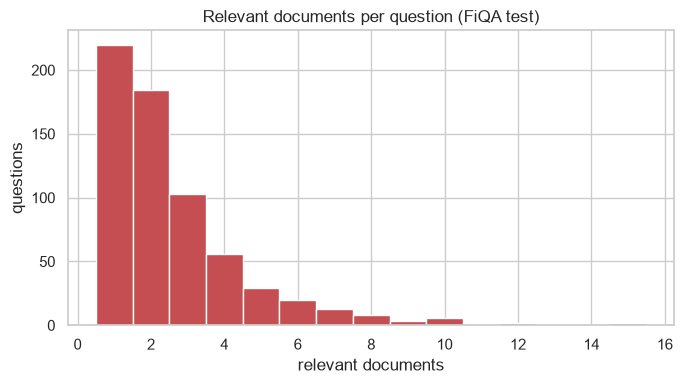

In [5]:
rel = np.array([len(v) for v in qrels.values()])
print(f"relevant documents per question: mean={rel.mean():.2f}  median={np.median(rel):.0f}  "
      f"min={rel.min()}  max={rel.max()}")
print(f"questions with exactly one relevant document: {(rel == 1).sum()} "
      f"({(rel == 1).mean():.1%})")

plt.figure(figsize=(7, 4))
plt.hist(rel, bins=np.arange(0.5, rel.max() + 1.5), color="#C44E52")
plt.title("Relevant documents per question (FiQA test)")
plt.xlabel("relevant documents"); plt.ylabel("questions")
plt.tight_layout(); plt.show()

A third of questions have exactly one relevant document, and the mean is
2.63. Two consequences:

- **`nDCG@10` is the right headline metric.** With a median of 2 relevant
  documents, `Precision@10` is capped near 0.2 for a perfect system, which
  makes it look like failure.
- **Top-5 passages is a reasonable generator budget.** It covers the mean
  case with room to spare, and passages beyond that mostly add tokens and
  distraction rather than evidence.

## What this means for the rest of the project

| Observation | Consequence |
|---|---|
| Median document is 90 words, tail runs to 17k | Passages are truncated at 1,200 characters before generation |
| MiniLM discards ~20% of corpus tokens | Its deficit vs bge-base is partly context length, not just model quality |
| No titles, 38 empty documents | Nothing to exploit in a title field; empties left in for comparability |
| 2.63 relevant documents per question | nDCG@10 as headline; 5 passages to the generator |